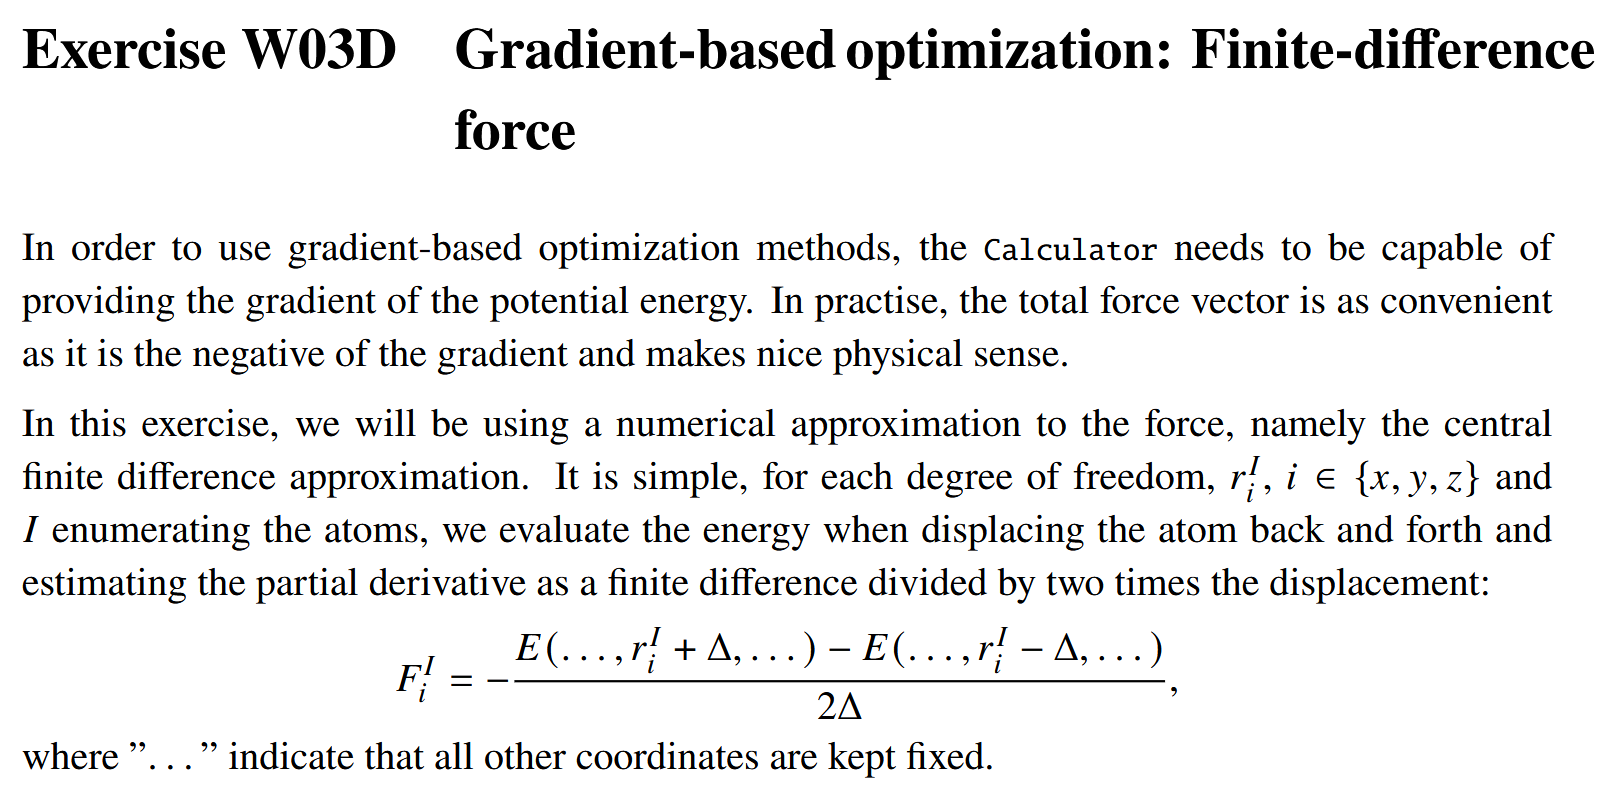

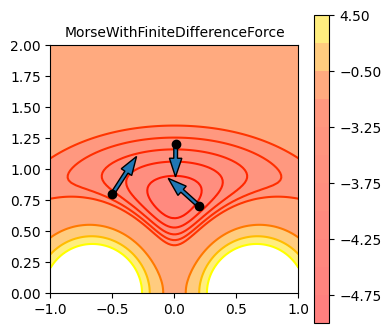

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from week03 import *

class MorseWithFiniteDifferenceForce(Morse):
    def forces(self, pos, delta=1e-6):
        N, dim = pos.shape
        forces = np.zeros(pos.shape)
        for i in range(N):
            for d in range(dim):
                # Positive displacement
                pos_forward = np.array(pos, copy=True)
                pos_forward[i, d] += delta
                e_forward = self.potential_energy(pos_forward)

                # Negative displacement
                pos_backward = np.array(pos, copy=True)
                pos_backward [i, d] -= delta
                e_backward = self.potential_energy(pos_backward)

                # Central difference
                forces[i, d] = -(e_forward - e_backward) / (2 * delta)
        
        return forces

calc = MorseWithFiniteDifferenceForce()

pos0 = [[-0.8, 0.6], [-0.65, 0.0], [0.65, 0.0]]
fig, ax = base_plot(pos0, calc)

# Making list again to keep pos0 unchanged?
p_list = [[-0.5, 0.8], [0.2, 0.7], [0.01, 1.2]]
for p0 in p_list:
    ax.plot(*p0, 'ko', zorder=20)
    pos = [p0, [-0.65, 0.0], [0.65, 0.0]]

    cluster = AtomicClusterBase2(calc, pos=pos, static=[False, True, True])

    scale = 0.1
    f = cluster.forces[0,:] * scale
    ax.arrow(*p0, *f, width=0.03, head_width=0.1, length_includes_head=True, facecolor='C0', zorder=10)
plt.show()

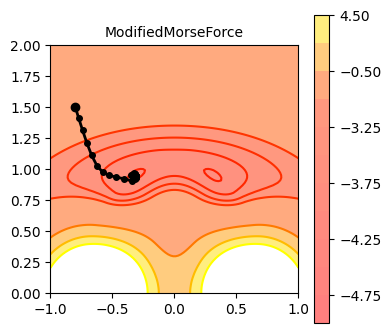

In [9]:
class ModifiedMorseForce(ModifiedMorse):
    def forces(self, pos, delta=1e-6):
        N, dim = pos.shape
        forces = np.zeros(pos.shape)
        for i in range(N):
            for d in range(dim):
                # Positive displacement
                pos_forward = np.array(pos, copy=True)
                pos_forward[i, d] += delta
                e_forward = self.potential_energy(pos_forward)

                # Negative displacement
                pos_backward = np.array(pos, copy=True)
                pos_backward [i, d] -= delta
                e_backward = self.potential_energy(pos_backward)

                # Central difference
                forces[i, d] = -(e_forward - e_backward) / (2 * delta)
        
        return forces



def gradient_descent(cluster, Nsteps=100, gamma=0.05):
    points = [cluster.get_positions()[0].copy()]
    for _ in range(Nsteps):
        pos = cluster.get_positions()
        forces = cluster.forces  

        pos += gamma * forces  
        
        cluster.set_positions(pos)
        
        points.append(cluster.get_positions()[0].copy())
        
    return np.array(points).transpose()

calc = ModifiedMorseForce()

pos0 = [[-0.8, 0.6], [-0.65, 0.0], [0.65, 0.0]]
fig, ax = base_plot(pos0, calc)

# Making list again to keep pos0 unchanged?
p0 = [-0.8, 1.5]

ax.plot(*p0, 'ko', zorder=20)
pos = [p0, [-0.65, 0.0], [0.65, 0.0]]

cluster = AtomicClusterBase2(calc, pos=pos, static=[False, True, True])

trajectory = gradient_descent(cluster, Nsteps=50, gamma=0.05)

ax.plot(trajectory[0], trajectory[1], 'k.-', linewidth=2, markersize=8, zorder=15)

plt.show()

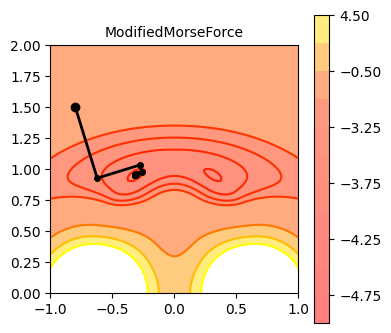

In [10]:
from scipy.optimize import fmin

def line_search(cluster, steps=100, fnorm_min=1e-5, xtol=1e-8, ftol=1e-8):
    test = cluster.copy()

    points = [cluster.get_positions()[0].copy()]
    
    def potential_energy_of_alpha(alpha, p):
        # Test position is the current position plus the step (alpha) times direction (p)
        test.set_positions(cluster.get_positions() + alpha * p)
        return test.potential_energy
        
    for i in range(steps):
        f = cluster.forces
        fnorm = np.linalg.norm(f)
        
        if fnorm < fnorm_min:
            break # Done


        # Normalized direction    
        p = f / fnorm
        
        alpha_opt = fmin(lambda alpha: potential_energy_of_alpha(alpha, p), 0.1, disp=False, xtol=xtol, ftol=ftol)
        
        cluster.set_positions(cluster.get_positions() + alpha_opt * p)
        
        points.append(cluster.get_positions()[0].copy())
        
    return np.array(points).transpose()

calc = ModifiedMorseForce()

pos0 = [[-0.8, 0.6], [-0.65, 0.0], [0.65, 0.0]]
fig, ax = base_plot(pos0, calc)

# Making list again to keep pos0 unchanged?
p0 = [-0.8, 1.5]

ax.plot(*p0, 'ko', zorder=20)
pos = [p0, [-0.65, 0.0], [0.65, 0.0]]

cluster = AtomicClusterBase2(calc, pos=pos, static=[False, True, True])

trajectory = line_search(cluster)

ax.plot(trajectory[0], trajectory[1], 'k.-', linewidth=2, markersize=8, zorder=15)

plt.show()